In [ ]:
import kagglehub
kmader_skin_cancer_mnist_ham10000_path = kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000')

print('Data source import complete.')


Data source import complete.


In [ ]:
!pip install tensorflow seaborn pillow

from PIL import Image ## To import and resize the image
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Flatten,Dense,LSTM,GRU
from tensorflow.keras.utils import to_categorical
#from tensorflow.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import itertools
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0032809.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0031479.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0030506.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0031986.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0033624.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029352.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0032582.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0033152.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0033974.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0031417.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029889.jpg
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_p

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


877/877 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5972 - loss: 1.2544 - val_accuracy: 0.6646 - val_loss: 1.1346
Epoch 2/20
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6752 - loss: 1.1292 - val_accuracy: 0.6646 - val_loss: 1.1163
Epoch 3/20
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6743 - loss: 1.1073 - val_accuracy: 0.6646 - val_loss: 1.1106
Epoch 4/20
877/877 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6691 - loss: 1.1079 - val_accuracy: 0.6646 - val_loss: 1.1018
Epoch 5/20
877/877 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6734 - loss: 1.0996 - val_accuracy: 0.6646 - val_loss: 1.1020
Epoch 6/20
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6823 - loss: 1.0734 - val_accuracy: 0.6646 - val_loss: 1.1011
Epoch 7/20
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6775 - loss: 1.1004 - val_accuracy: 0.6646 - val_loss: 1.0982
Epoch 8/20
877/877 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6767 - loss: 1.0999 - val_accuracy: 0.6646 - val_

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


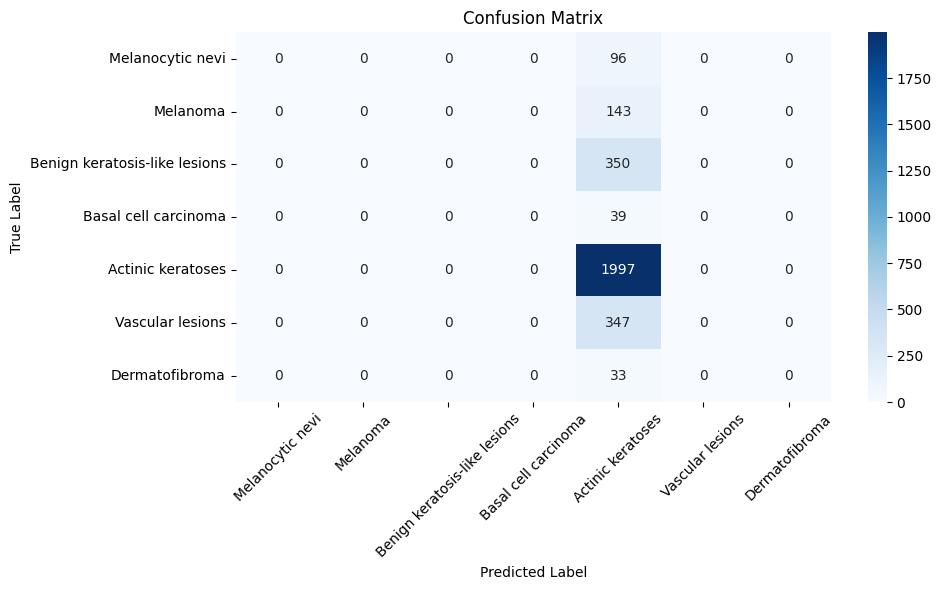

In [ ]:
import pandas as pd
import numpy as np
import cv2
import pywt
from glob import glob
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from skimage.feature import graycomatrix, graycoprops

# === Load metadata ===
df = pd.read_csv('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

# === Mapping label klasifikasi ===
lesion_mapping = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

# === Ambil path semua gambar ===
base_dir = '/kaggle/input/skin-cancer-mnist-ham10000'
imageid_path = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(base_dir, '*', '*.jpg'))
}

df['path'] = df['image_id'].map(imageid_path.get)
df['cell_type'] = df['dx'].map(lesion_mapping.get)
df['label'] = pd.Categorical(df['cell_type']).codes

# === Fungsi untuk preprocessing dan ekstraksi fitur ===
def preprocess_and_extract(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (125, 100))
    img_filtered = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
    Z = img_filtered.reshape((-1, 3)).astype(np.float32)
    kmeans = cv2.kmeans(Z, 2, None, (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0), 10, cv2.KMEANS_RANDOM_CENTERS)[1]
    segmented = kmeans.reshape((img_filtered.shape[0], img_filtered.shape[1]))
    gray = cv2.cvtColor(img_filtered, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)
    glcm_feats = [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0]
    ]
    cA, (cH, cV, cD) = pywt.dwt2(gray, 'db1')
    wave_feats = [np.mean(cA), np.mean(cH), np.mean(cV), np.mean(cD)]
    return glcm_feats + wave_feats

# === Terapkan ekstraksi fitur ke semua gambar ===
df = df.dropna(subset=['path'])
df['features'] = df['path'].map(preprocess_and_extract)

# === Siapkan X dan y ===
X = np.array(df['features'].tolist())
y = to_categorical(df['label'], num_classes=7)

# === Split data ===
X = np.expand_dims(X, axis=1)  # untuk RNN (samples, timesteps, features)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === Model RNN ===
model = Sequential()
model.add(SimpleRNN(32, input_shape=(1, X.shape[2]), activation='tanh'))
model.add(Dense(7, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=8, validation_data=(X_test, y_test))

# === Evaluasi Model ===
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# === Tampilkan metrik evaluasi ===
report = classification_report(y_true_classes, y_pred_classes, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\n=== Classification Report ===")
print(report_df.round(4))

# === Confusion Matrix ===
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_true_classes, y_pred_classes)
print(cm)

# === Visualisasi Confusion Matrix ===
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lesion_mapping.values(), yticklabels=lesion_mapping.values())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 30s 113ms/step - accuracy: 0.2362 - loss: 2.1220 - val_accuracy: 0.0562 - val_loss: 1.9511
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.1819 - loss: 1.8354 - val_accuracy: 0.5584 - val_loss: 1.2122
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.4486 - loss: 1.5216 - val_accuracy: 0.5181 - val_loss: 1.4109
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 147ms/step - accuracy: 0.4482 - loss: 1.6060 - val_accuracy: 0.3997 - val_loss: 1.4358
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 22s 101ms/step - accuracy: 0.4346 - loss: 1.4399 - val_accuracy: 0.4725 - val_loss: 1.3355
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.4377 - loss: 1.4031 - val_accuracy: 0.4779 - val_loss: 1.2749
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.4884 - loss: 1.3911 - val_accuracy: 0.4825 - val_loss: 1.2838
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.4347 - loss: 1.3062

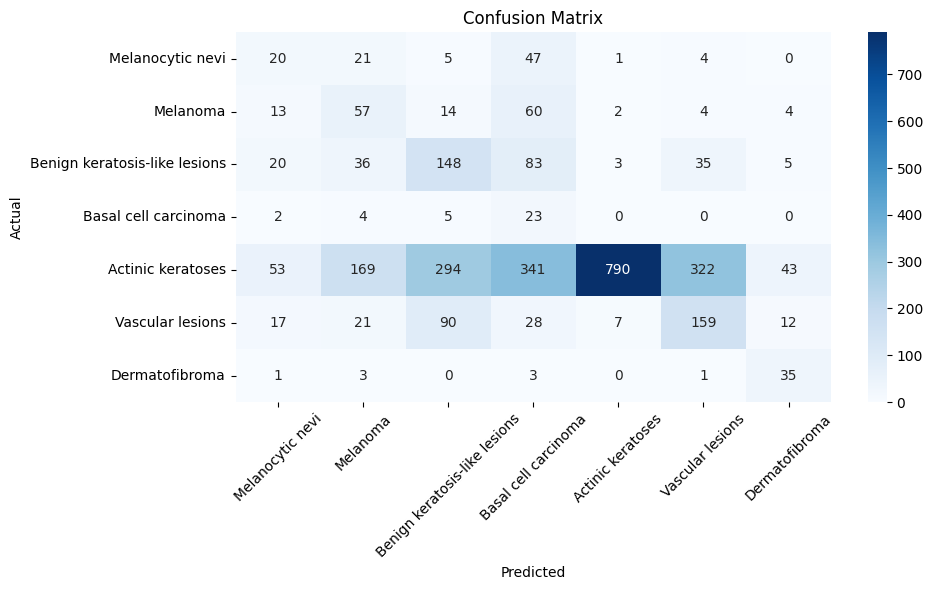

In [ ]:
import pandas as pd
import numpy as np
import cv2
import os
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns

# === Load metadata ===
df = pd.read_csv('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

# === Mapping label ===
lesion_mapping = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

# === Ambil path gambar ===
base_dir = '/kaggle/input/skin-cancer-mnist-ham10000'
imageid_path = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(base_dir, '*', '*.jpg'))
}
df['path'] = df['image_id'].map(imageid_path.get)
df['cell_type'] = df['dx'].map(lesion_mapping.get)
df['label'] = pd.Categorical(df['cell_type']).codes

# === Load gambar jadi array ===
def load_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (100, 100))
    return img / 255.0

df = df.dropna(subset=['path'])
df['image'] = df['path'].map(load_image)

X = np.array(df['image'].tolist())
y = to_categorical(df['label'], num_classes=7)

# === Split data ===
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X, y, df['label'].values, test_size=0.3, random_state=42, stratify=df['label'].values
)

# === Class weights untuk ketidakseimbangan kelas ===
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(weights))

# === Image Augmentation ===
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# === CNN Model ===
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# === Train model dengan augmentasi ===
model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

# === Evaluasi ===
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n=== Classification Report ===")
print(classification_report(y_true_classes, y_pred_classes, target_names=list(lesion_mapping.values())))

# === Confusion Matrix ===
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes), annot=True, fmt='d',
            xticklabels=lesion_mapping.values(),
            yticklabels=lesion_mapping.values(), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


220/220 ━━━━━━━━━━━━━━━━━━━━ 30s 114ms/step - accuracy: 0.4227 - loss: 1.9609 - val_accuracy: 0.3993 - val_loss: 1.5687
Epoch 2/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.4010 - loss: 1.7264 - val_accuracy: 0.4509 - val_loss: 1.3878
Epoch 3/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.3954 - loss: 1.6479 - val_accuracy: 0.4785 - val_loss: 1.4373
Epoch 4/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.4759 - loss: 1.4240 - val_accuracy: 0.4835 - val_loss: 1.2294
Epoch 5/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.4728 - loss: 1.4318 - val_accuracy: 0.3877 - val_loss: 1.3050
Epoch 6/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.4711 - loss: 1.4769 - val_accuracy: 0.4619 - val_loss: 1.3916
Epoch 7/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.4743 - loss: 1.3552 - val_accuracy: 0.5045 - val_loss: 1.2755
Epoch 8/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.4950 - loss: 1.3459 - val_accura

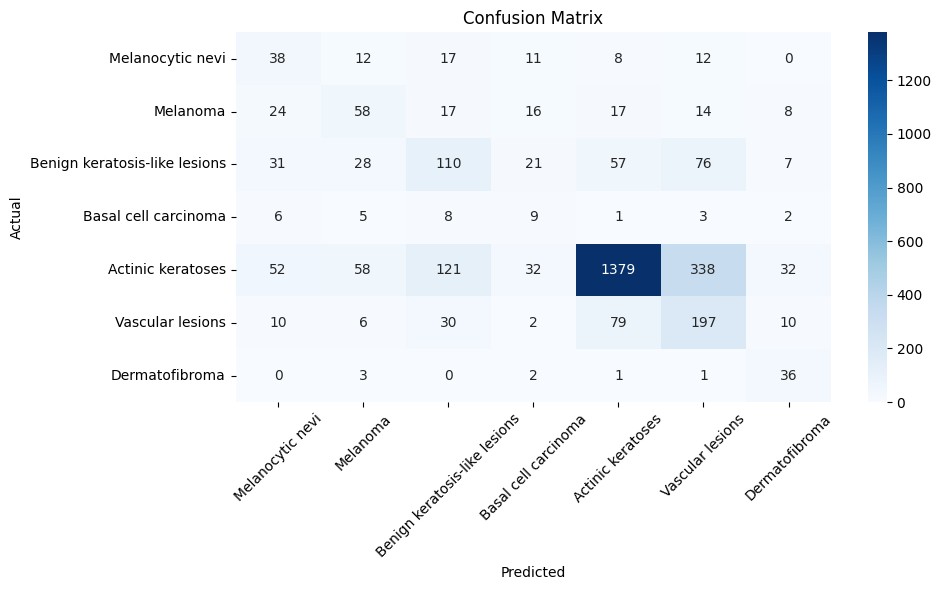

In [ ]:
#EARLY STOPPING ADDED
import pandas as pd
import numpy as np
import cv2
import os
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# === Load metadata ===
df = pd.read_csv('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

# === Mapping label ===
lesion_mapping = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

# === Ambil path gambar ===
base_dir = '/kaggle/input/skin-cancer-mnist-ham10000'
imageid_path = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(base_dir, '*', '*.jpg'))
}
df['path'] = df['image_id'].map(imageid_path.get)
df['cell_type'] = df['dx'].map(lesion_mapping.get)
df['label'] = pd.Categorical(df['cell_type']).codes

# === Load gambar jadi array ===
def load_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (100, 100))
    return img / 255.0

df = df.dropna(subset=['path'])
df['image'] = df['path'].map(load_image)

X = np.array(df['image'].tolist())
y = to_categorical(df['label'], num_classes=7)

# === Split data ===
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X, y, df['label'].values, test_size=0.3, random_state=42, stratify=df['label'].values
)

# === Class weights untuk ketidakseimbangan kelas ===
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(weights))

# === Image Augmentation ===
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# === CNN Model ===
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# === Early Stopping ===
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# === Train model dengan augmentasi ===
model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=40,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stopping]
)

# === Evaluasi ===
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n=== Classification Report ===")
print(classification_report(y_true_classes, y_pred_classes, target_names=list(lesion_mapping.values())))

# === Confusion Matrix ===
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes), annot=True, fmt='d',
            xticklabels=lesion_mapping.values(),
            yticklabels=lesion_mapping.values(), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
